## 5.3 熱力圖（Heatmap）

### 1. 定義  
熱力圖（Heatmap）是一種以顏色深淺表示數值大小的視覺化方式，常用來呈現矩陣資料，尤其適合展示變數間的相關係數。


### 2. 範例圖表與說明  

In [4]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
path = '/content/drive/MyDrive/Colab Notebooks/CH5_dataset/datasets'
img_path = '/content/drive/MyDrive/Colab Notebooks/CH5_dataset/images'

Mounted at /content/drive


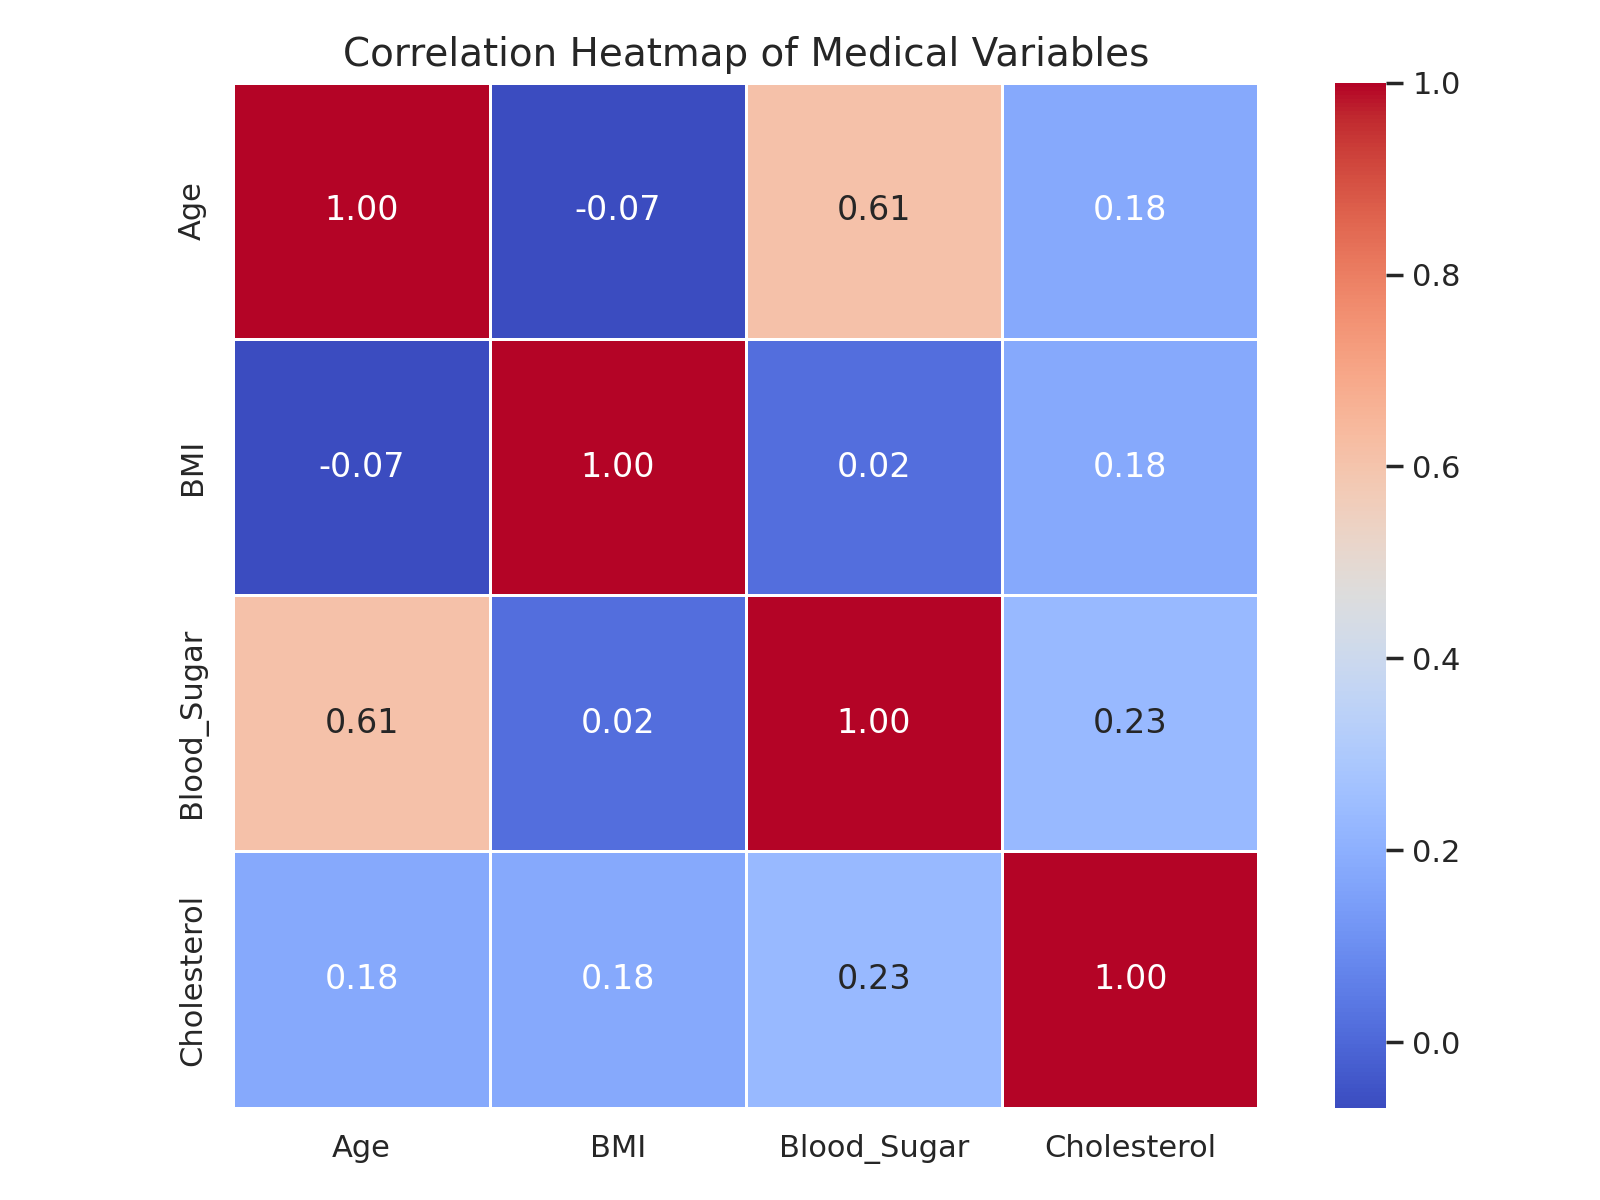

In [7]:
from IPython import display

display.Image(img_path +"/"+ 'Heatmap-1.png', width = 600)

**觀察與解釋**：  

- 年齡（Age）與血糖（Blood Sugar）、膽固醇（Cholesterol）呈現正相關  
- BMI 與膽固醇也有中度正相關  
- 血糖與膽固醇相關性偏低  

此圖能快速幫助我們理解變數間的線性關聯程度，是進行建模與變數選擇前的重要步驟。

### 3. 適用情況  
- 多變數之間相關性分析（Correlation Matrix）  
- 顯示交叉分類後的數值表格（如交叉計數、平均值）  
- 任意矩陣型數值資料的可視化


### 4. 優缺點  
- **優點**：  
  - 能同時呈現多組變數間關聯性  
  - 色彩視覺化能快速辨識極高或極低的關係  

- **缺點**：  
  - 色彩過多可能難以精確比較差異  
  - 對於小變化不敏感，無法呈現方向性或因果性


### 5. 實際案例與圖表  

- **醫療領域**：年齡、BMI、血糖、膽固醇間的相關性分析  
- **電子商務**：各產品類型 × 地區 × 銷售金額統計  
- **製造領域**：製程參數之間的變異與共變關係


### 6. 實作範例：醫學領域 - 醫療變數相關性分析

#### 📁 資料說明

模擬 200 筆病患資料，包含年齡、BMI、血糖值與膽固醇。

| Age | BMI  | Blood_Sugar | Cholesterol |
|-----|------|-------------|-------------|
| 51  | 23.2 | 115.3       | 198.5       |
| 67  | 27.1 | 143.9       | 213.4       |
| ... | ...  | ...         | ...         |

### 💻 Python 程式碼（含詳細註解）
`sns.heatmap()`: [API Doc](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

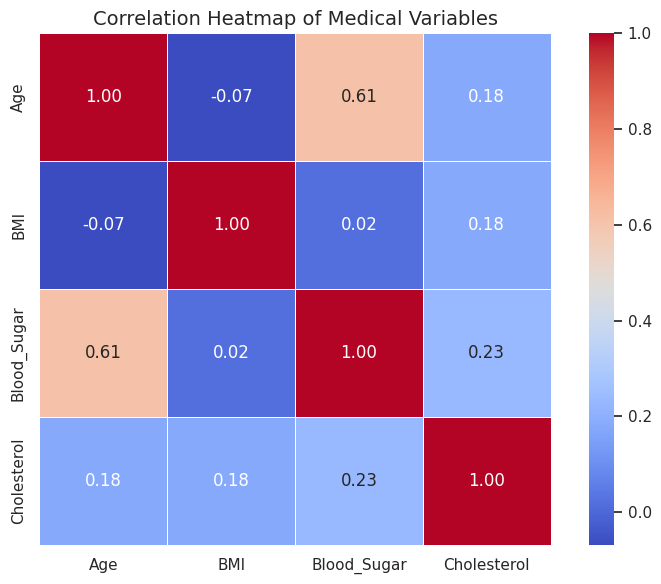

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 載入資料
from pathlib import Path

data_file = "medical_variables_for_heatmap.csv"

df = pd.read_csv(path+"/"+data_file)

# 計算相關係數矩陣
corr_matrix = df.corr()

# 設定 Seaborn 樣式
sns.set(style="white")

# 繪製熱力圖
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(
    corr_matrix,
    annot=True,          # 顯示數值
    fmt=".2f",           # 小數點位數
    cmap="coolwarm",     # 色彩主題
    linewidths=0.5,      # 格線寬度
    square=True          # 方格比例一致
)

plt.title("Correlation Heatmap of Medical Variables", fontsize=14)
plt.tight_layout()
plt.show()

### Try it!：6. 實作範例：醫學領域 - 醫療變數相關性分析
相關矩陣是對稱的，上三角其實是重複資訊，把它遮掉讓圖更清爽。

**程式要求**
1. 讀取 `datasets/medical_variables_for_heatmap.csv`，計算相關係數矩陣。
2. 使用 `np.triu` 建立上三角遮罩。
3. 繪製只顯示下三角的熱力圖（`mask` 參數）。

#### 📌 額外補充參數與調整參考表

| 參數         | 說明                            | 範例值                   |
|--------------|----------------------------------|--------------------------|
| `annot`      | 是否顯示數值                     | `True`, `False`          |
| `fmt`        | 數值顯示格式                     | `".2f"`, `".1f"`         |
| `cmap`       | 色彩主題                         | `"coolwarm"`, `"viridis"`|
| `linewidths` | 每格之間的線條寬度               | `0.3`, `0.5`, `1.0`       |
| `square`     | 是否方格等寬                     | `True`, `False`          |


#### 📝 練習任務建議

1. **修改 `cmap`**：試用 `"YlGnBu"`, `"magma"` 等不同色系  
2. **關閉格線 (`linewidths=0`)**：觀察視覺變化  
3. **移除 `annot=True` 僅以顏色呈現**  
4. **自行新增欄位**（如 Blood_Pressure），加入矩陣分析  
5. **調整 `square=False`** 測試非等比例格子的視覺效果
